### Import Libraries

In [57]:
import pandas as pd
import numpy as np
import os

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.model_selection import GridSearchCV

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score
)

### Create Image Folder

In [58]:
if not os.path.exists("images"):
    os.makedirs("images")


### Load Dataset

In [59]:
df = pd.read_csv("data/water_potability.csv")

print("="*50)
print("First 5 Rows")
print("="*50)

print(df.head())

print("="*50)
print("Dataset Shape")
print("="*50)

print(df.shape)

print("="*50)
print("Dataset Information")
print("="*50)

df.info()

First 5 Rows
         ph    Hardness        Solids  Chloramines     Sulfate  Conductivity  \
0       NaN  204.890455  20791.318981     7.300212  368.516441    564.308654   
1  3.716080  129.422921  18630.057858     6.635246         NaN    592.885359   
2  8.099124  224.236259  19909.541732     9.275884         NaN    418.606213   
3  8.316766  214.373394  22018.417441     8.059332  356.886136    363.266516   
4  9.092223  181.101509  17978.986339     6.546600  310.135738    398.410813   

   Organic_carbon  Trihalomethanes  Turbidity  Potability  
0       10.379783        86.990970   2.963135           0  
1       15.180013        56.329076   4.500656           0  
2       16.868637        66.420093   3.055934           0  
3       18.436524       100.341674   4.628771           0  
4       11.558279        31.997993   4.075075           0  
Dataset Shape
(3276, 10)
Dataset Information
<class 'pandas.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   

### Missing Values

In [60]:
print("="*50)
print("Missing Values")
print(df.isnull().sum())

imputer = SimpleImputer(strategy="median")

df.iloc[:, :-1] = imputer.fit_transform(df.iloc[:, :-1])

print("="*50)
print("Missing Values After Cleaning")
print(df.isnull().sum())

Missing Values
ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64
Missing Values After Cleaning
ph                 0
Hardness           0
Solids             0
Chloramines        0
Sulfate            0
Conductivity       0
Organic_carbon     0
Trihalomethanes    0
Turbidity          0
Potability         0
dtype: int64


### Exploratory Data Analysis

                ph     Hardness        Solids  Chloramines      Sulfate  \
count  3276.000000  3276.000000   3276.000000  3276.000000  3276.000000   
mean      7.074194   196.369496  22014.092526     7.122277   333.608364   
std       1.470040    32.879761   8768.570828     1.583085    36.143851   
min       0.000000    47.432000    320.942611     0.352000   129.000000   
25%       6.277673   176.850538  15666.690297     6.127421   317.094638   
50%       7.036752   196.967627  20927.833607     7.130299   333.073546   
75%       7.870050   216.667456  27332.762127     8.114887   350.385756   
max      14.000000   323.124000  61227.196008    13.127000   481.030642   

       Conductivity  Organic_carbon  Trihalomethanes    Turbidity   Potability  
count   3276.000000     3276.000000      3276.000000  3276.000000  3276.000000  
mean     426.205111       14.284970        66.407478     3.966786     0.390110  
std       80.824064        3.308162        15.769958     0.780382     0.487849  


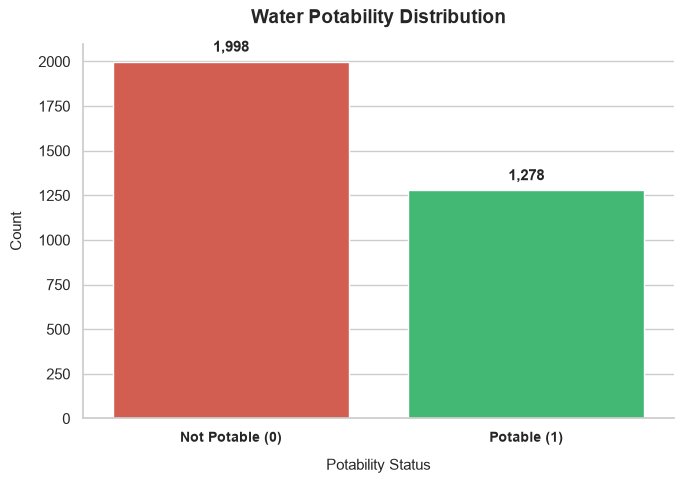

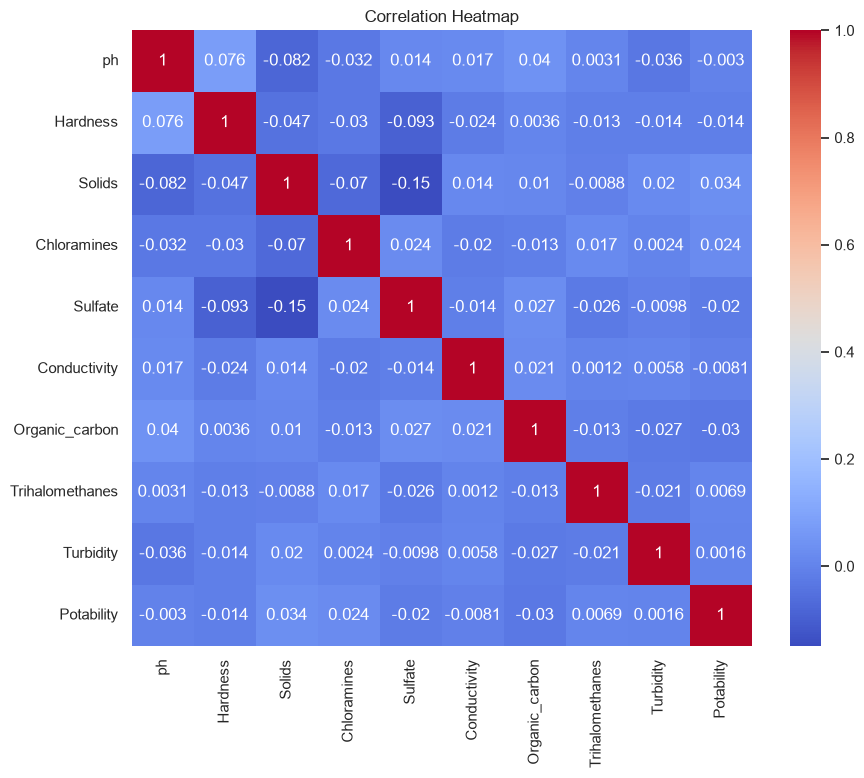

In [61]:
print(df.describe())

# Set a modern visual style
sns.set_theme(style="whitegrid", font="sans-serif")

# Create figure
fig, ax = plt.subplots(figsize=(7, 5))

# Plot with custom colors
palette = ["#e74c3c", "#2ecc71"]  # Red for Not Potable (0), Green for Potable (1)
sns.countplot(x="Potability", data=df, ax=ax, palette=palette, hue="Potability", legend=False)

# Add exact count values on top of each bar
for p in ax.patches:
    height = int(p.get_height())
    ax.annotate(
        f"{height:,}",
        (p.get_x() + p.get_width() / 2.0, height),
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold",
        xytext=(0, 5),
        textcoords="offset points",
    )

# Improve labels and title
ax.set_title("Water Potability Distribution", fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Potability Status", fontsize=11, labelpad=10)
ax.set_ylabel("Count", fontsize=11, labelpad=10)

# Replace numeric 0 and 1 with descriptive labels
ax.set_xticks([0, 1])
ax.set_xticklabels(["Not Potable (0)", "Potable (1)"], fontsize=10, fontweight="bold")

# Clean border lines (removes top and right axis spines)
sns.despine(top=True, right=True)

# Save and display
plt.tight_layout()
plt.savefig("images/potability_distribution.png")
plt.show()

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.savefig("images/correlation_heatmap.png")
plt.show()

### Split Features & Target

In [62]:
X = df.drop("Potability", axis=1)
y = df["Potability"]

### Train Test Split

In [63]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

### Feature Scaling

In [64]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Decision Tree

DECISION TREE
DECISION TREE
              precision    recall  f1-score   support

           0       0.68      0.62      0.65       412
           1       0.44      0.51      0.47       244

    accuracy                           0.58       656
   macro avg       0.56      0.56      0.56       656
weighted avg       0.59      0.58      0.58       656

Accuracy : 0.5762
Precision: 0.4397
Recall   : 0.5082
F1 Score : 0.4715


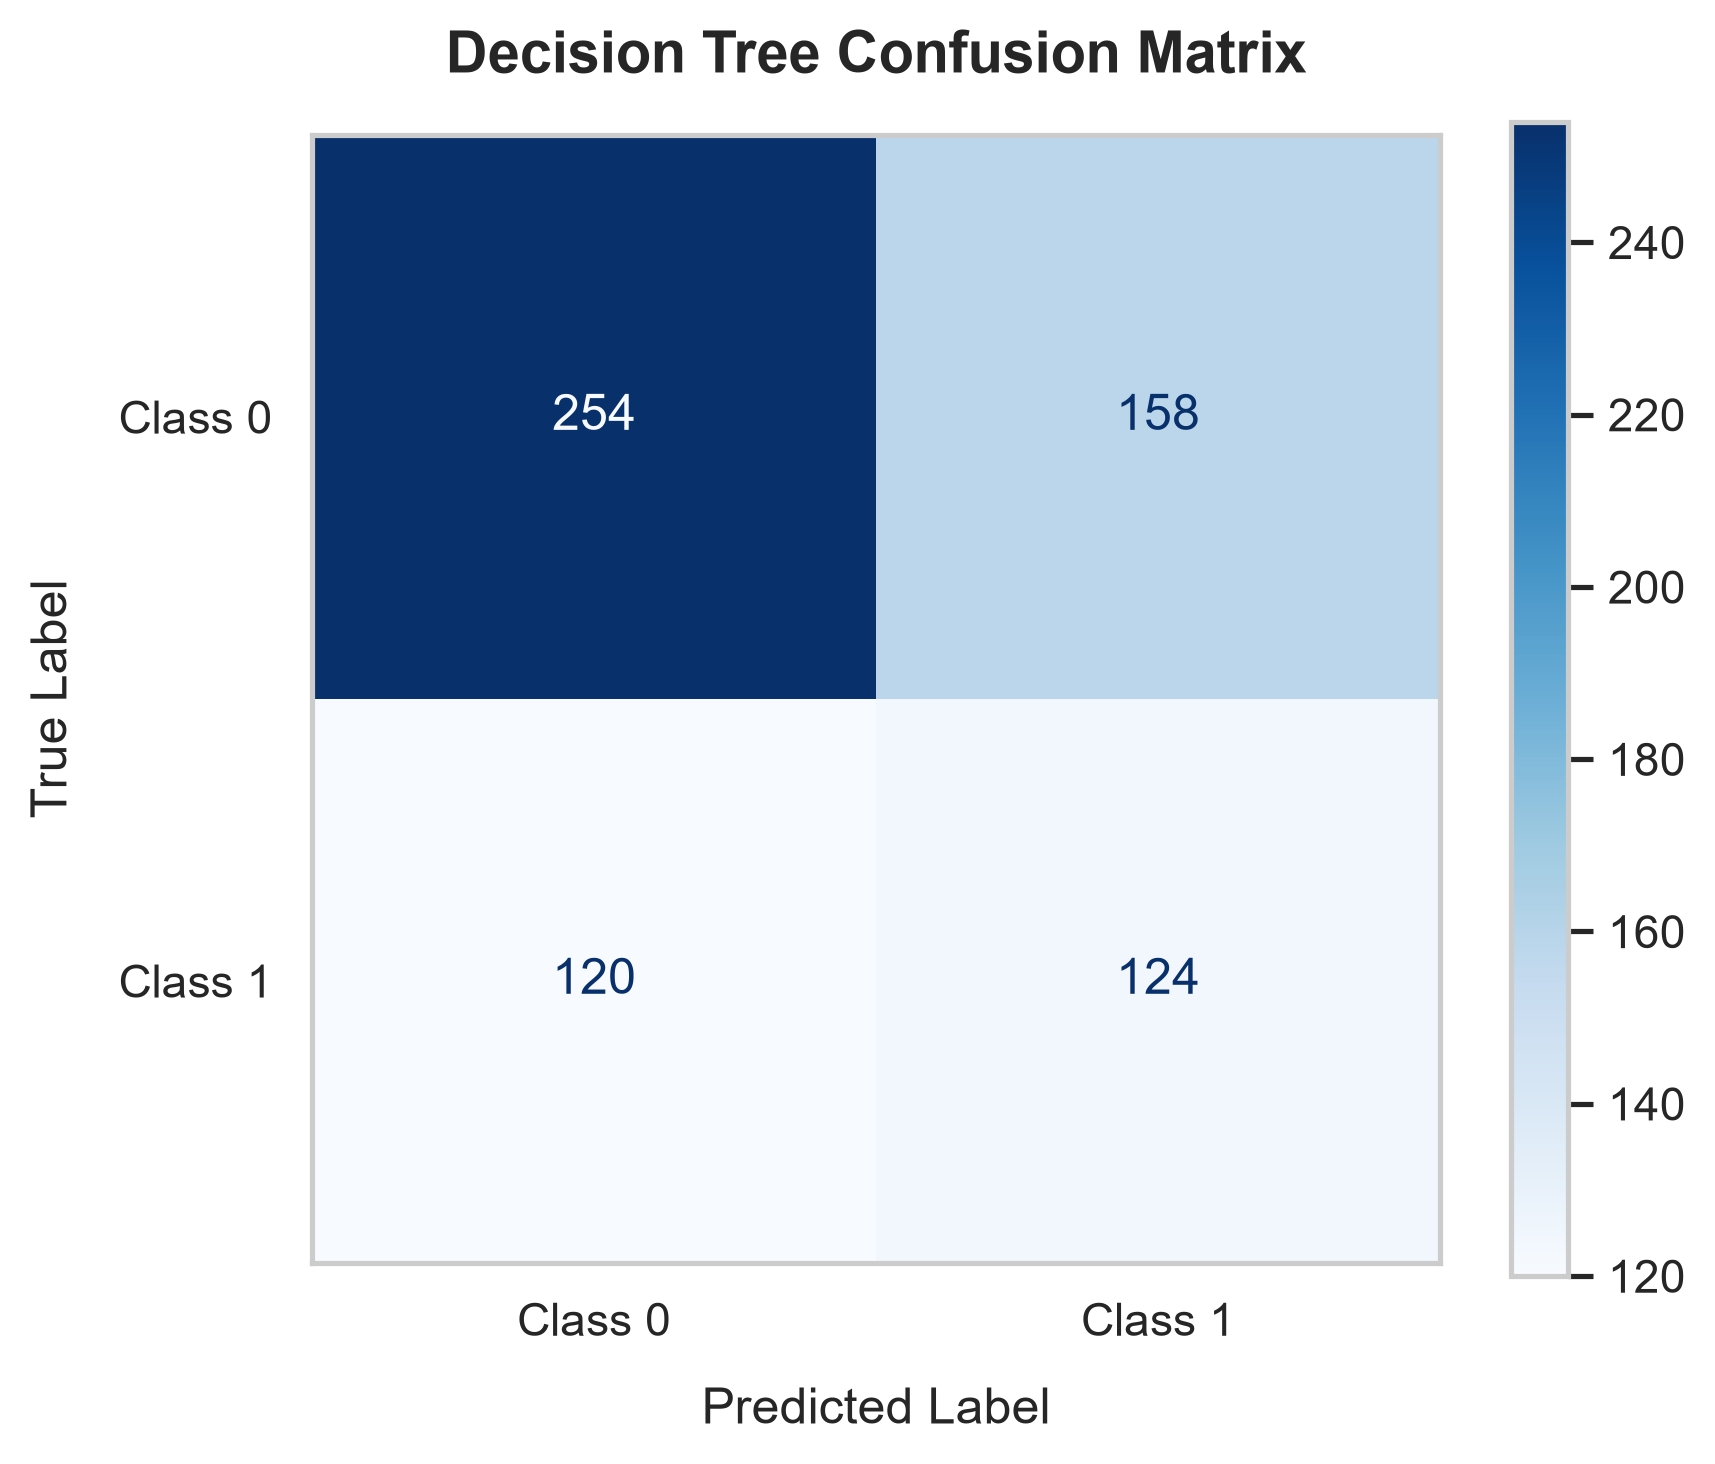

In [65]:
# print("="*50)
print("DECISION TREE")

tree = DecisionTreeClassifier(random_state=42)

tree.fit(X_train,y_train)

y_pred_tree = tree.predict(X_test)

# print(classification_report(y_test,y_pred_tree))

# tree_accuracy = accuracy_score(y_test,y_pred_tree)
# tree_precision = precision_score(y_test,y_pred_tree)
# tree_recall = recall_score(y_test,y_pred_tree)
# tree_f1 = f1_score(y_test,y_pred_tree)

# print("Accuracy :",tree_accuracy)
# print("Precision:",tree_precision)
# print("Recall   :",tree_recall)
# print("F1 Score :",tree_f1)

# cm = confusion_matrix(y_test,y_pred_tree)

# ConfusionMatrixDisplay(cm).plot()

# plt.title("Decision Tree Confusion Matrix")
# plt.savefig("images/confusion_matrix_tree.png")
# plt.show()
print("=" * 50)
print("DECISION TREE")

# Train Model
tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train, y_train)

# Predict
y_pred_tree = tree.predict(X_test)

# Print Metrics Report
print(classification_report(y_test, y_pred_tree))

tree_accuracy = accuracy_score(y_test, y_pred_tree)
tree_precision = precision_score(y_test, y_pred_tree)
tree_recall = recall_score(y_test, y_pred_tree)
tree_f1 = f1_score(y_test, y_pred_tree)

print(f"Accuracy : {tree_accuracy:.4f}")
print(f"Precision: {tree_precision:.4f}")
print(f"Recall   : {tree_recall:.4f}")
print(f"F1 Score : {tree_f1:.4f}")

# Plot Styled Confusion Matrix
cm = confusion_matrix(y_test, y_pred_tree)

fig, ax = plt.subplots(figsize=(6, 5), dpi=300)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm, 
    display_labels=["Class 0", "Class 1"]  # Replace with actual class names if preferred
)
disp.plot(cmap="Blues", ax=ax, colorbar=True, values_format="d")

# Visual Refinements
ax.grid(False)
plt.title("Decision Tree Confusion Matrix", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Predicted Label", fontsize=12, labelpad=10)
plt.ylabel("True Label", fontsize=12, labelpad=10)

plt.tight_layout()
plt.savefig("images/confusion_matrix_tree.png", dpi=300, bbox_inches="tight")
plt.show()

### Decision Tree Grid Search

In [66]:
print("="*50)
print("Grid Search Decision Tree")

param_tree = {
    "criterion":["gini","entropy"],
    "max_depth":[3,5,7,10,None],
    "min_samples_split":[2,5,10]
}

grid_tree = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_tree,
    cv=5,
    scoring="accuracy"
)

grid_tree.fit(X_train,y_train)

print("Best Parameters:",grid_tree.best_params_)
print("Best Score:",grid_tree.best_score_)

Grid Search Decision Tree
Best Parameters: {'criterion': 'gini', 'max_depth': 7, 'min_samples_split': 10}
Best Score: 0.6408396946564885


###  Model Comparison

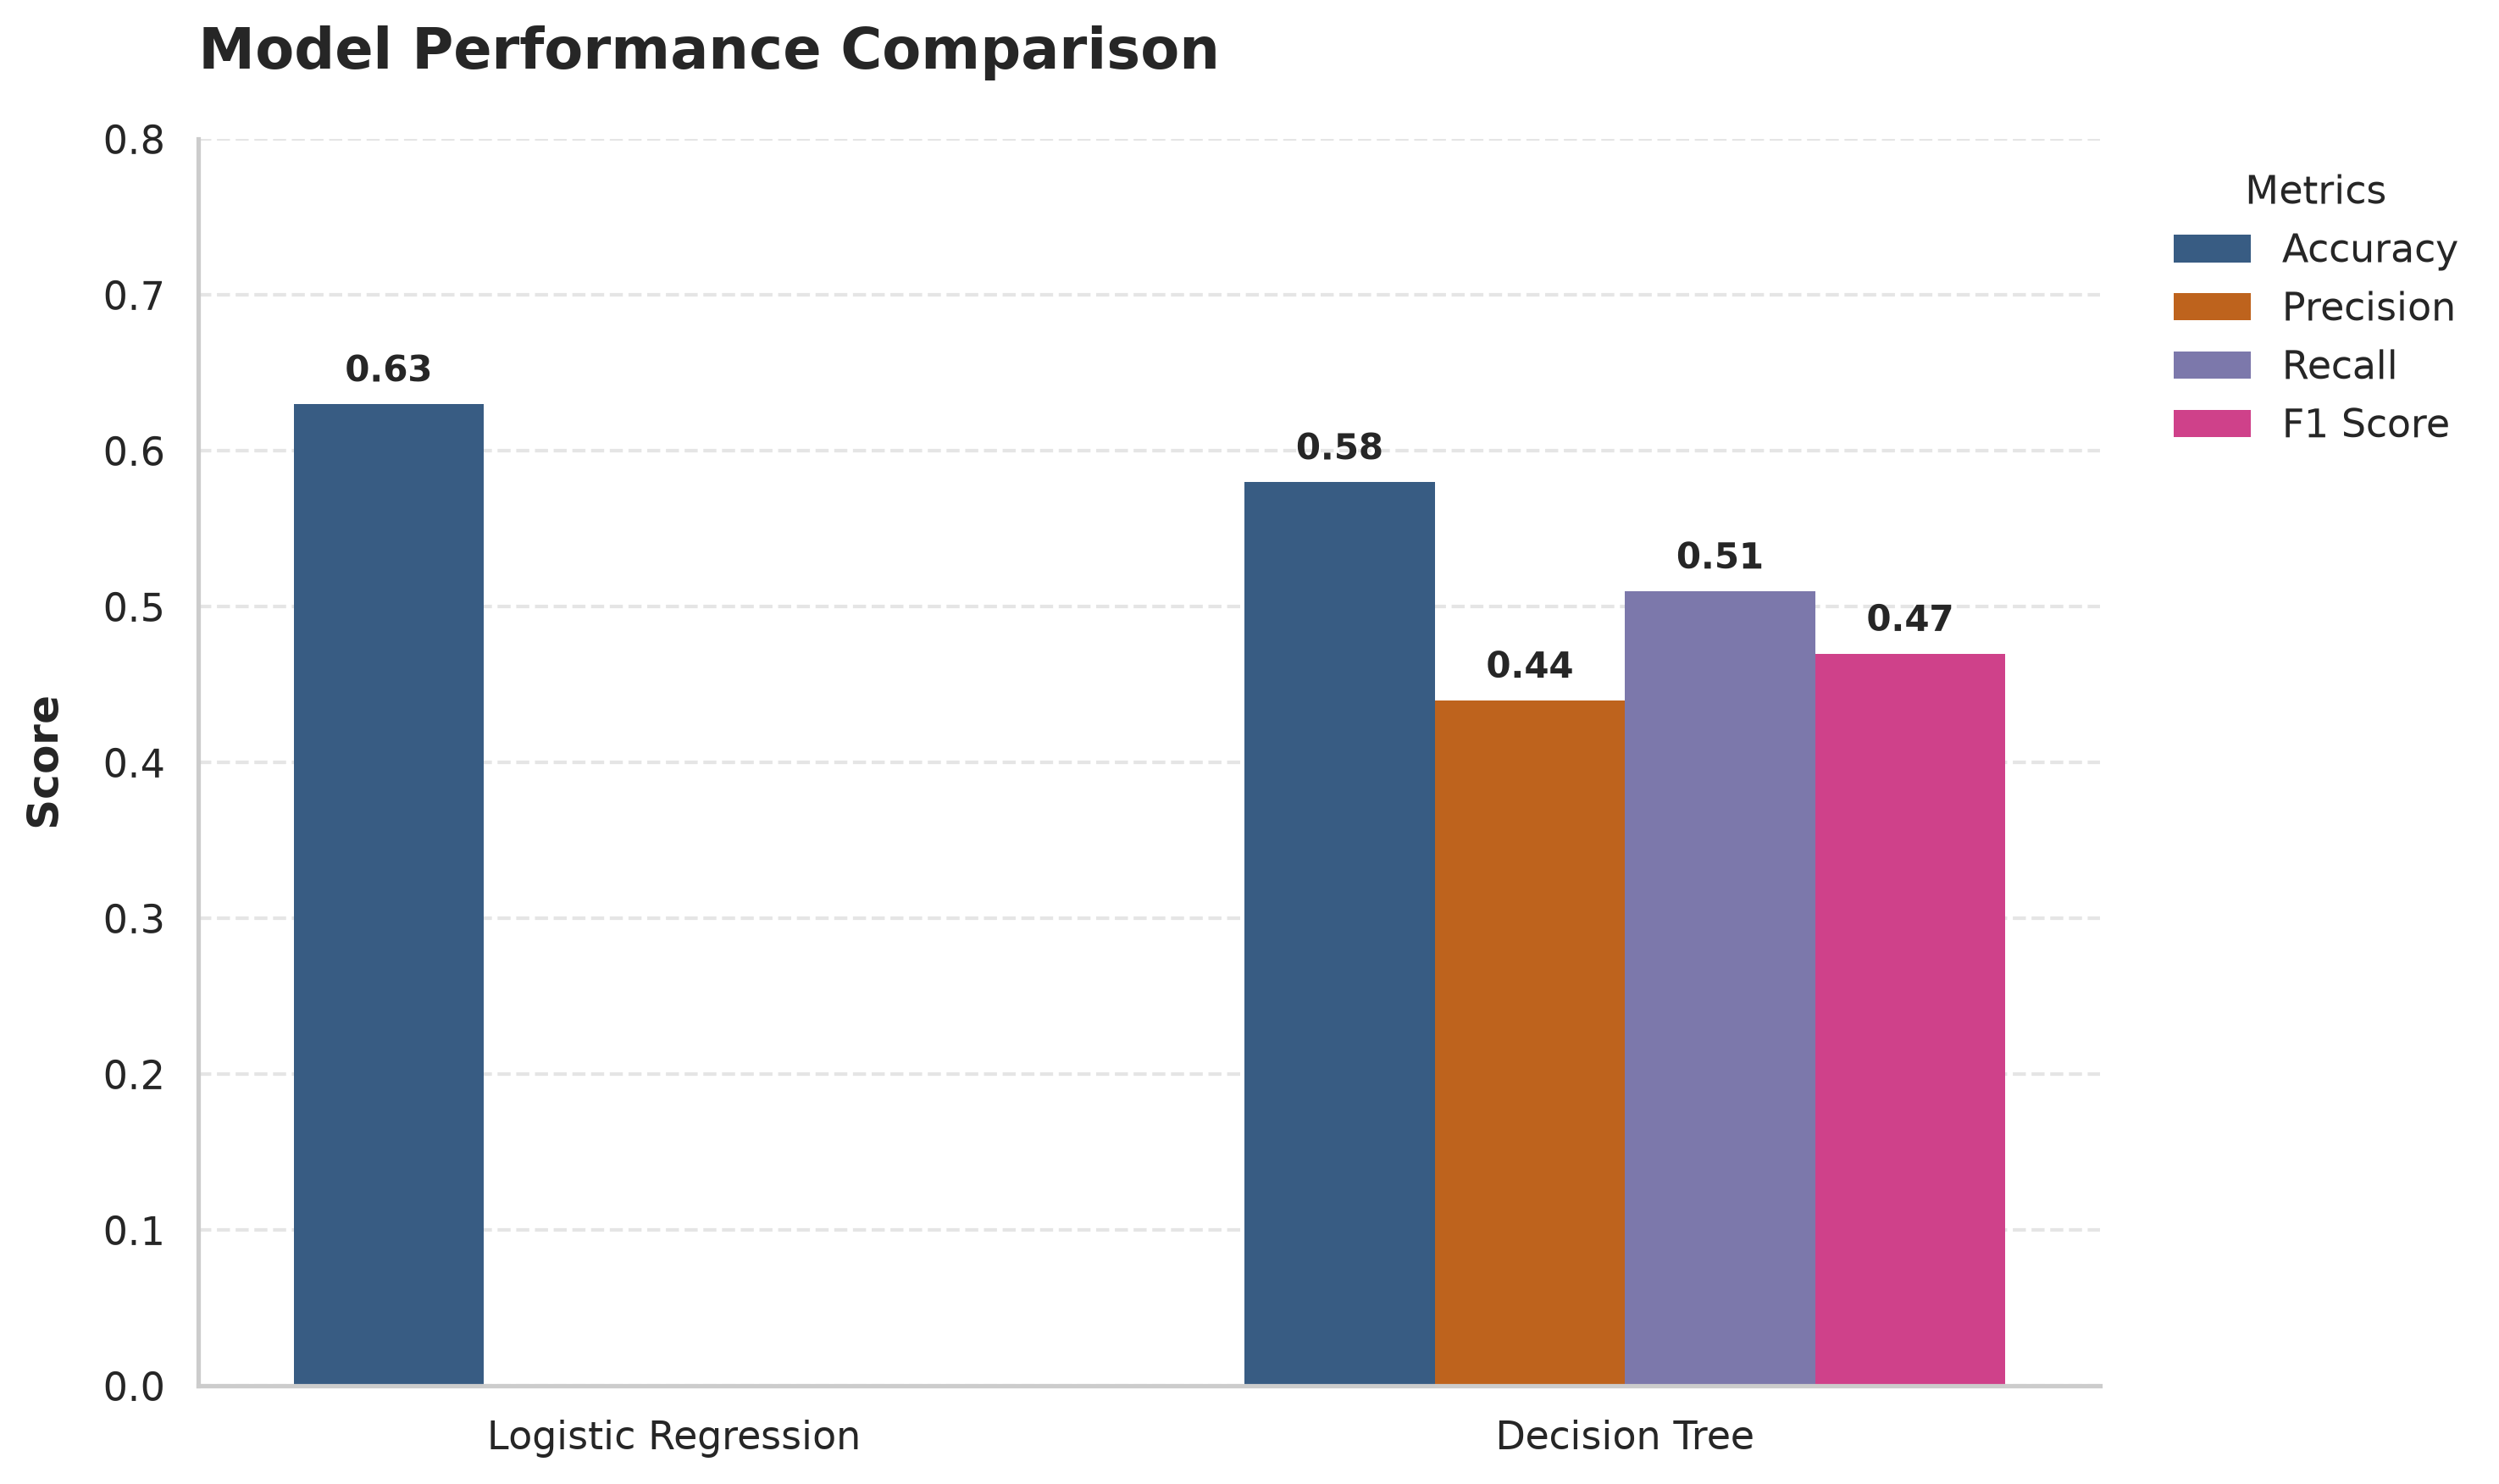

In [67]:

# Set clean aesthetic style
sns.set_theme(style="whitegrid")
plt.rcParams["font.sans-serif"] = "DejaVu Sans"

# 1. Prepare Data
# Logistic Regression missing Precision, Recall, F1 (set to 0 for plot)
data = {
    "Model": [
        "Logistic Regression",
        "Logistic Regression",
        "Logistic Regression",
        "Logistic Regression",
        "Decision Tree",
        "Decision Tree",
        "Decision Tree",
        "Decision Tree",
    ],
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
    ],
    "Score": [0.63, 0.00, 0.00, 0.00, 0.58, 0.44, 0.51, 0.47],
}

df = pd.DataFrame(data)

# Filter out zero values so empty bars don't clutter the layout
df_plot = df[df["Score"] > 0]

# 2. Setup Figure
fig, ax = plt.subplots(figsize=(10, 6), dpi=300)

# Professional color palette
palette = {
    "Accuracy": "#2b5c8f",
    "Precision": "#d95f02",
    "Recall": "#7570b3",
    "F1 Score": "#e7298a",
}

# 3. Create Grouped Bar Plot
chart = sns.barplot(
    data=df_plot,
    x="Model",
    y="Score",
    hue="Metric",
    palette=palette,
    edgecolor="none",
    ax=ax,
)

# 4. Add Value Labels on Top of Bars
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(
            f"{height:.2f}",
            (p.get_x() + p.get_width() / 2.0, height),
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold",
            xytext=(0, 4),
            textcoords="offset points",
        )

# 5. Styling & Cleanups
ax.set_ylim(0, 0.8)
ax.set_ylabel("Score", fontsize=12, fontweight="bold", labelpad=10)
ax.set_xlabel("", fontsize=12)
ax.set_title(
    "Model Performance Comparison",
    fontsize=16,
    fontweight="bold",
    pad=20,
    loc="left",
)

# Horizontal gridlines only
ax.grid(True, axis="y", linestyle="--", alpha=0.5)
ax.grid(False, axis="x")

# Clean up spines (outer frame)
sns.despine(top=True, right=True, left=False, bottom=False)

# Legend positioning
plt.legend(
    title="Metrics",
    title_fontsize="11",
    frameon=True,
    facecolor="white",
    edgecolor="none",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

plt.tight_layout()
plt.savefig("images/model_comparison.png")
plt.show()